## Import libraries

In [ ]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))  # Add parent folder

from src.utils import count_feature_categories, load_metabric_data

In [ ]:
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from watermark import watermark

warnings.simplefilter(action="ignore", category=FutureWarning)

print(watermark())

Last updated: 2026-04-21T00:00:41.742176+03:00

Python implementation: CPython
Python version       : 3.12.0
IPython version      : 9.12.0

Compiler    : Clang 14.0.6 
OS          : Darwin
Release     : 25.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit



In [ ]:
print(watermark(packages="numpy,pandas,seaborn,shap,sklearn"))

numpy  : 2.4.3
pandas : 3.0.1
seaborn: 0.13.2
shap   : 0.51.0
sklearn: 1.8.0



In [ ]:
RANDOM_STATE=42

## Load Data

In [ ]:
# local load
#df = pd.read_csv('../data/METABRIC_RNA_Mutation.csv', low_memory=False)

# or directly from kaggle
df = load_metabric_data()

df.shape

Fetching METABRIC dataset from Kaggle...


(1904, 693)

In [ ]:
df['pam50_+_claudin-low_subtype'].value_counts()

pam50_+_claudin-low_subtype
LumA           679
LumB           461
Her2           220
claudin-low    199
Basal          199
Normal         140
NC               6
Name: count, dtype: int64

In [ ]:
# We isolate only the patients classified as Luminal A ('LumA').
# This guarantees our model only looks at clinical variance within this "low-risk" group.

df_LumA = df[df['pam50_+_claudin-low_subtype'] == 'LumA'].copy()

In [ ]:
df_LumA.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,...,gpr32_mut,kras_mut,nf2_mut,chek2_mut,ldlrap1_mut,clrn2_mut,acvrl1_mut,agtr2_mut,cdkn2a_mut,ctnna1_mut,magea8_mut,prr16_mut,dtwd2_mut,akt2_mut,braf_mut,foxo1_mut,nt5e_mut,ccnd3_mut,nr3c1_mut,prkg1_mut,tbl1xr1_mut,frmd3_mut,smad2_mut,sgcd_mut,spaca1_mut,rasgef1b_mut,hist1h2bc_mut,nr2f1_mut,klrg1_mut,mbl2_mut,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living,-1.3800,0.2777,-1.2154,0.5296,-0.0136,-0.2659,1.3594,0.7961,0.5419,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10,36,85.49,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumA,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Post,3,Left,0.0,1.0,3.044,IDC,132.033333,0,Positive,1,ER+/HER2- Low Prolif,22.0,4.0,Died of Disease,-0.4601,-0.2692,-0.7247,-0.6742,-0.6333,-0.6192,0.2709,-0.4980,1.2944,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
13,46,83.02,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,GAIN,Positive,Ductal/NST,1,Post,5,Left,24.0,2.0,6.072,IDC,14.133333,0,Positive,1,NaN,36.0,2.0,Died of Other Causes,0.5076,-0.2461,0.5441,0.8156,-0.0250,0.4019,1.2208,0.8715,1.2463,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23,68,51.01,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,1.0,LOSS,Negative,Tubular/ cribriform,1,Post,3,Left,1.0,2.0,3.024,IDC,103.133333,1,Positive,1,NaN,12.0,2.0,Living,-1.1307,0.2092,-0.5120,2.0882,0.2387,-0.4897,-0.4562,-0.4724,1.5497,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
29,97,78.19,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,8,Left,3.0,2.0,5.060,IDC,98.700000,1,Positive,1,NaN,30.0,2.0,Living,-0.9922,1.0902,1.7172,-0.0410,0.5870,-0.3803,2.8209,0.5220,-0.2723,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Typical data pre-processing

In [ ]:
# We want to predict purely breast cancer mortality (1) vs surviving/other death (0).

df_LumA['target_mortality'] = df_LumA['death_from_cancer'].apply(
    lambda x: 1 if str(x).strip().lower() == 'died of disease' else 0
)

df_LumA['target_mortality'].value_counts()

target_mortality
0    533
1    146
Name: count, dtype: int64

In [ ]:
total_luma = len(df_LumA)
died_luma = len(df_LumA[df_LumA['target_mortality'] == 1])
lived_luma = len(df_LumA[df_LumA['target_mortality'] == 0])
mortality_rate = (died_luma / total_luma) * 100

print("Survival Stats:\n------")
print(f"Subset of patients assigned with Luminal A: {total_luma}")
print(f"Patients who LIVED (Expected): {lived_luma}")
print(f"Patients who DIED (The Discordant Group): {died_luma}")
print(f"Discordance Rate: {mortality_rate:.1f}%\n------")

Survival Stats:
------
Subset of patients assigned with Luminal A: 679
Patients who LIVED (Expected): 533
Patients who DIED (The Discordant Group): 146
Discordance Rate: 21.5%
------


In [ ]:
# Drop columns that would cause data leakage (like survival_months) or target variables
leakage_cols = ['patient_id', 'overall_survival_months',
                 'overall_survival', 'death_from_cancer', 'target_mortality']

# Automatically select all numeric columns from the isolated Luminal A dataset
numeric_cols = df_LumA.select_dtypes(include=['number']).columns.tolist()

# Filter out the leakage columns
features = [col for col in numeric_cols if col not in leakage_cols]

X = df_LumA[features]
y = df_LumA['target_mortality']

print(f"Shape of newly created dataset: {X.shape}")

Shape of newly created dataset: (679, 500)


In [ ]:
# Subset of 'Luminal A' into the two outcomes

LumA_died = df_LumA[df_LumA['target_mortality'] == 1]
LumA_lived = df_LumA[df_LumA['target_mortality'] == 0]

## Getting prepared for data modeling

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [ ]:
# we impute missing numeric values with the median of that specific feature.

missing_values = X.isnull().sum()

columns_to_impute = missing_values[missing_values > 0].index.tolist()
print(missing_values[missing_values > 0].to_string())

total_imputed = missing_values.sum()
print(f"\n\nTotal imputed data points: {total_imputed} (out of {X.shape[0] * X.shape[1]} total points)")

# detect numerical columns

numeric_columns = X.select_dtypes(include="number").columns

# introduce preprocessing pipelines

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_columns)
    ],
    remainder="passthrough"
)

preprocessor.set_output(transform="pandas")
preprocessor.verbose_feature_names_out = False

neoplasm_histologic_grade     31
mutation_count                 7
tumor_size                     1
tumor_stage                  159


Total imputed data points: 198 (out of 339500 total points)


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

## Interpretable Models Benchmark

Models implemented into [imodels](https://github.com/csinva/imodels) and [interpret.ml](https://interpret.ml/docs/index.html).

Each model is followed by its interpretability output.

In [19]:
%%time
# EBM (Explainable Boosting Machine)
from interpret.glassbox import ExplainableBoostingClassifier

ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train_scaled, y_train)

test_proba = ebm.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

print(f"EBM | Test AUC = {test_auc:.3f}")


EBM | Test AUC = 0.653
CPU times: total: 10.8 s
Wall time: 4min 21s


In [ ]:
# EBM Explainability: per-feature contribution plots
from interpret import show

ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7001/2445511285728/ -->

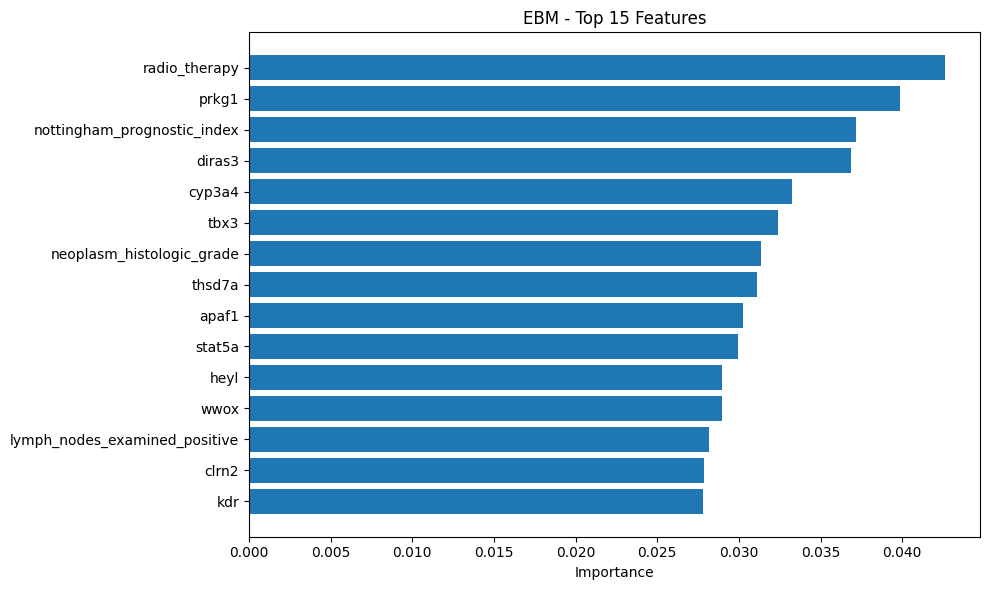

In [ ]:
# EBM: Top 15 most important features
import matplotlib.pyplot as plt

importances = list(ebm.term_importances())
names = list(ebm.term_names_)

feat_imp = sorted(zip(names, importances), key=lambda x: x[1], reverse=True)[:15]
feat_names = [f[0] for f in feat_imp][::-1]
feat_vals = [f[1] for f in feat_imp][::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(feat_names)), feat_vals)
plt.yticks(range(len(feat_names)), feat_names)
plt.xlabel('Importance')
plt.title('EBM - Top 15 Features')
plt.tight_layout()
plt.show()

In [22]:
%%time
# FIGS (Fast Interpretable Greedy-Tree Sums)
from imodels import FIGSClassifier

figs = FIGSClassifier(max_rules=20, random_state=42)
figs.fit(X_train_scaled, y_train)

test_proba = figs.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

print(f"FIGS | Test AUC = {test_auc:.3f}")


FIGS | Test AUC = 0.585
CPU times: total: 906 ms
Wall time: 912 ms


In [ ]:
# FIGS Explainability: print the learned trees
# FIGS produces a sum of small trees that can be read directly
print(figs)

> ------------------------------
> FIGS-Fast Interpretable Greedy-Tree Sums:
> 	Predictions are made by summing the "Val" reached by traversing each tree.
> 	For classifiers, a softmax function is then applied to the sum.
> ------------------------------
nottingham_prognostic_index <= 0.399 (Tree #0 root)
	stat5a <= -1.394 (split)
		aurka <= 0.231 (split)
			Val: 0.0 1.0 (leaf)
			ctcf <= 0.854 (split)
				Val: 0.994 0.006 (leaf)
				Val: -0.006 1.006 (leaf)
		diras3 <= -0.345 (split)
			shank2 <= 1.544 (split)
				mmp26 <= -1.086 (split)
					Val: 0.274 0.726 (leaf)
					pdgfra <= 0.741 (split)
						Val: 0.902 0.098 (leaf)
						cdkn2c <= 0.086 (split)
							Val: 0.188 0.812 (leaf)
							Val: 0.988 0.012 (leaf)
				Val: 0.125 0.875 (leaf)
			Val: 0.948 0.052 (leaf)
	map2k2 <= 0.030 (split)
		gpr32 <= -1.182 (split)
			Val: 0.25 0.75 (leaf)
			Val: 0.862 0.138 (leaf)
		clrn2 <= -0.609 (split)
			Val: 0.087 0.913 (leaf)
			apaf1 <= 0.042 (split)
				gps2 <= 1.179 (split)
					Val: 0.

In [24]:
%%time
# RuleFit
from imodels import RuleFitClassifier

rulefit = RuleFitClassifier(random_state=42)
rulefit.fit(X_train_scaled, y_train)

test_proba = rulefit.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

print(f"RuleFit | Test AUC = {test_auc:.3f}")


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. p

RuleFit | Test AUC = 0.668
CPU times: total: 3.83 s
Wall time: 3.83 s


In [ ]:
# RuleFit Explainability: top rules ranked by importance
import numpy as np
import pandas as pd

rules = rulefit.rules_without_feature_names_
coefs = rulefit.coef

n_rules = len(rules)
rule_coefs = coefs[:n_rules]

rules_df = pd.DataFrame({
    'rule': rules,
    'coef': rule_coefs
})
rules_df = rules_df[rules_df['coef'] != 0]
rules_df = rules_df.reindex(rules_df['coef'].abs().sort_values(ascending=False).index)

print(f"Total non-zero rules: {len(rules_df)}")
print(f"\nTop 15 rules by coefficient magnitude:")
for _, row in rules_df.head(15).iterrows():
    print(f"  coef={row['coef']:+.4f} | {row['rule']}")

Total non-zero rules: 1

Top 15 rules by coefficient magnitude:
  coef=-0.0581 | X_332 > -2.1603 and X_343 <= 0.88081 and X_7 <= 2.22919


In [26]:
%%time
# SkopeRules
from imodels import SkopeRulesClassifier

skope = SkopeRulesClassifier(random_state=42)
skope.fit(X_train_scaled, y_train)

test_proba = skope.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

print(f"SkopeRules | Test AUC = {test_auc:.3f}")


SkopeRules | Test AUC = 0.537
CPU times: total: 1.28 s
Wall time: 1.29 s


In [ ]:
# SkopeRules Explainability: deduplicated rules
# Each rule is a human-readable condition with no redundancy
for i, rule in enumerate(skope.rules_):
    print(f"Rule {i+1}: {rule}")

Rule 1: mmp26 > -1.10473 and nottingham_prognostic_index > 2.23286 and slc29a1 > 0.05855
Rule 2: lymph_nodes_examined_positive <= 2.21987 and plagl1 > 0.09529 and stat5a <= -1.03806
Rule 3: nottingham_prognostic_index <= 0.39877 and ptprm > -0.507 and stat5a <= -1.39371
Rule 4: col6a3 > 0.51698 and nottingham_prognostic_index <= 0.39877 and stat5a <= -1.03806
Rule 5: ctnna1 > -0.52986 and lymph_nodes_examined_positive > 2.21987
Rule 6: mapt > -1.05706 and mmp26 <= -1.10473 and peg3 <= -0.15279
Rule 7: bmpr1a <= -0.01556 and nottingham_prognostic_index > 2.23286
Rule 8: mdm2 > 1.05684 and nottingham_prognostic_index <= 0.39877 and tgfbr3 <= 0.44555
Rule 9: mdm2 > 1.05684 and nottingham_prognostic_index <= 0.39877 and tgfbr3 > 0.44555


In [28]:
%%time
# BoostedRules
from imodels import BoostedRulesClassifier

boosted = BoostedRulesClassifier(random_state=42)
boosted.fit(X_train_scaled, y_train)

test_proba = boosted.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

print(f"BoostedRules | Test AUC = {test_auc:.3f}")


BoostedRules | Test AUC = 0.745
CPU times: total: 281 ms
Wall time: 289 ms


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but BoostedRulesClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# BoostedRules Explainability: decision stumps with weights
# Each stump is a single threshold on a single feature
import numpy as np

for i, (est, weight) in enumerate(zip(
    boosted.estimators_, boosted.estimator_weights_
)):
    if hasattr(est, 'tree_'):
        tree = est.tree_
        feat_idx = tree.feature[0]
        threshold = tree.threshold[0]
        feat_name = X_train_scaled.columns[feat_idx]
        print(f"Stump {i+1:2d}: IF {feat_name:<35s} <= {threshold:+.3f}  (weight={weight:.3f})")
    else:
        print(f"Stump {i+1:2d}: {est} (weight={weight:.3f})")

Stump  1: IF nottingham_prognostic_index         <= +0.399  (weight=1.292)
Stump  2: IF nottingham_prognostic_index         <= +0.399  (weight=0.554)
Stump  3: IF apaf1                               <= +0.028  (weight=0.545)
Stump  4: IF stat5a                              <= -0.314  (weight=0.513)
Stump  5: IF pms2                                <= +1.119  (weight=0.321)
Stump  6: IF mmp26                               <= -1.105  (weight=0.447)
Stump  7: IF cxcr1                               <= -1.017  (weight=0.381)
Stump  8: IF e2f3                                <= +0.801  (weight=0.459)
Stump  9: IF hey2                                <= -1.253  (weight=0.259)
Stump 10: IF prps2                               <= +0.640  (weight=0.243)
Stump 11: IF sik2                                <= +1.167  (weight=0.308)
Stump 12: IF sik2                                <= +1.167  (weight=0.234)
Stump 13: IF atm                                 <= +0.401  (weight=0.273)
Stump 14: IF abcb11      

In [30]:
%%time
# GreedyTree (CART)
from imodels import GreedyTreeClassifier

gtree = GreedyTreeClassifier(random_state=42)
gtree.fit(X_train_scaled, y_train)

test_proba = gtree.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

print(f"GreedyTree | Test AUC = {test_auc:.3f}")


GreedyTree | Test AUC = 0.523
CPU times: total: 125 ms
Wall time: 127 ms


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GreedyTreeClassifier was fitted without feature names
  warnings.warn(


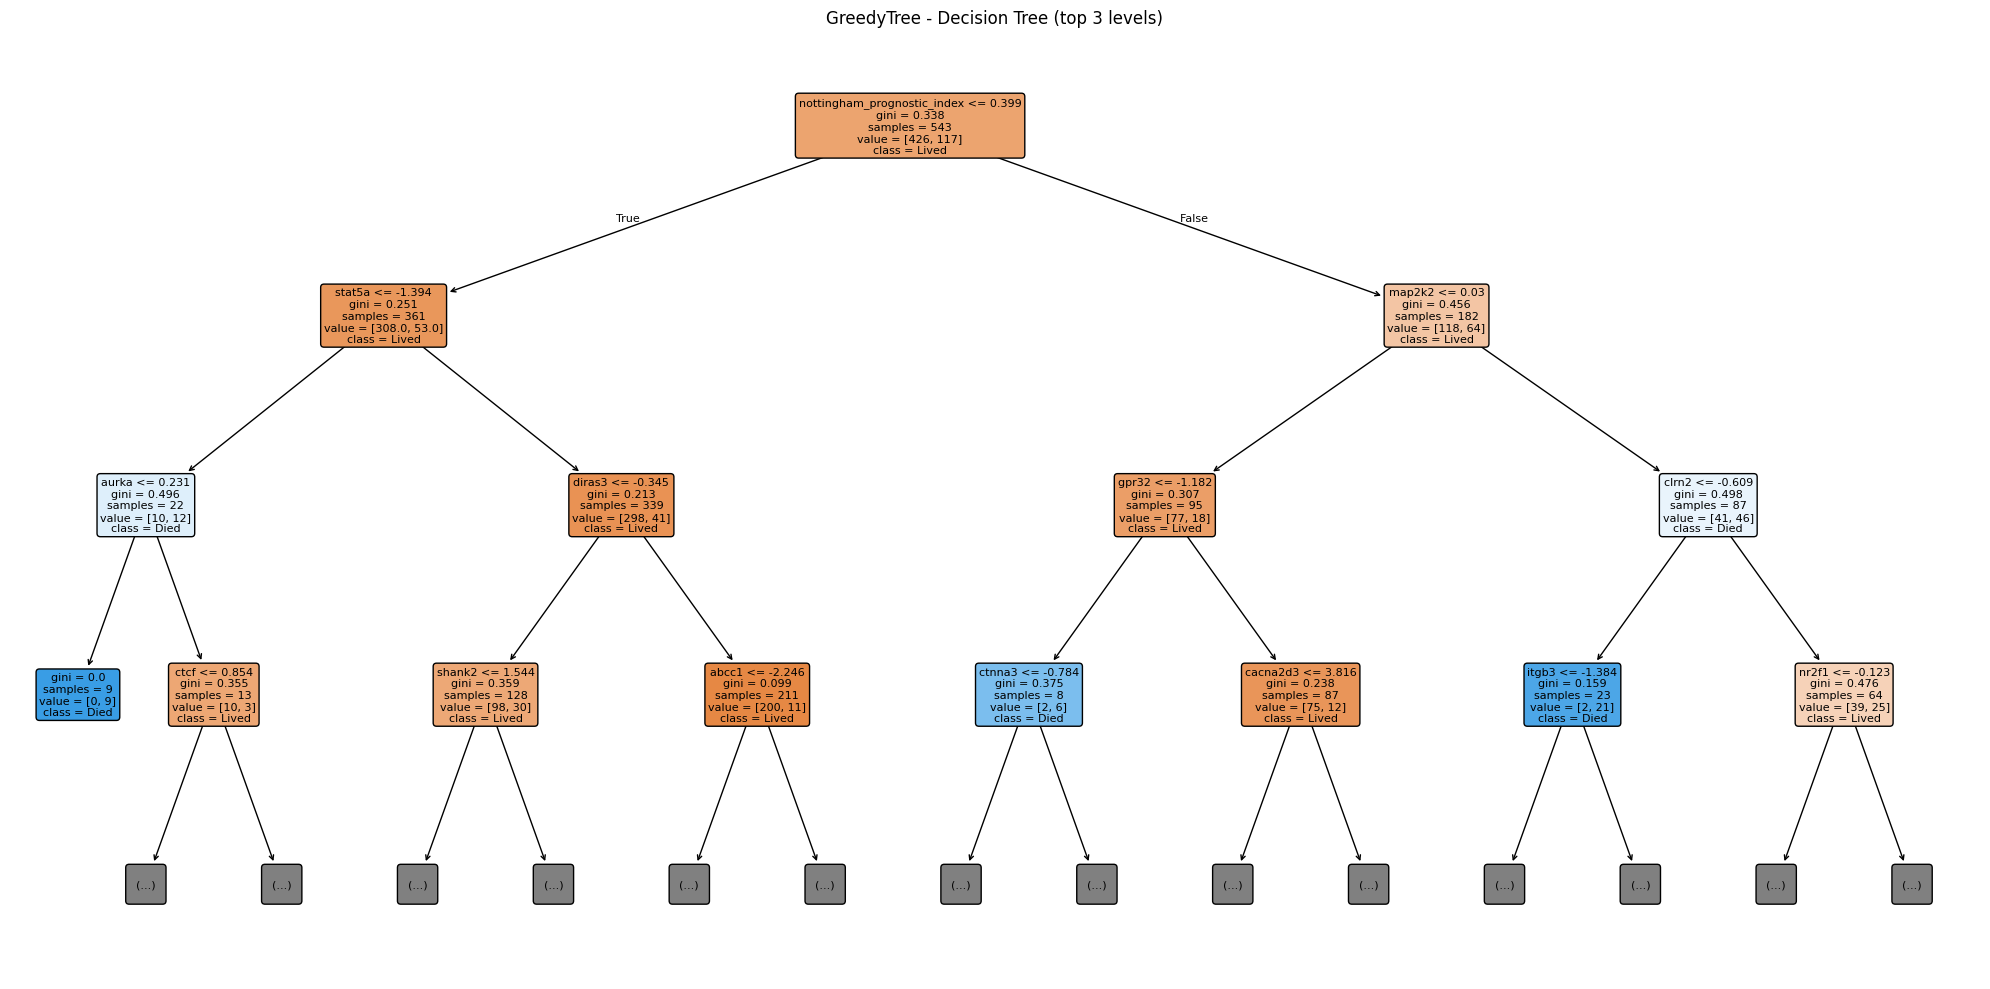

In [ ]:
# GreedyTree Explainability: visualize the decision tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    gtree,
    feature_names=list(X_train_scaled.columns),
    class_names=['Lived', 'Died'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('GreedyTree - Decision Tree (top 3 levels)')
plt.tight_layout()
plt.show()

In [32]:
%%time
# TreeGAM
from imodels import TreeGAMClassifier

tgam = TreeGAMClassifier(random_state=42)
tgam.fit(X_train_scaled, y_train)

test_proba = tgam.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

print(f"TreeGAM | Test AUC = {test_auc:.3f}")


TreeGAM | Test AUC = 0.646
CPU times: total: 10.3 s
Wall time: 10.3 s


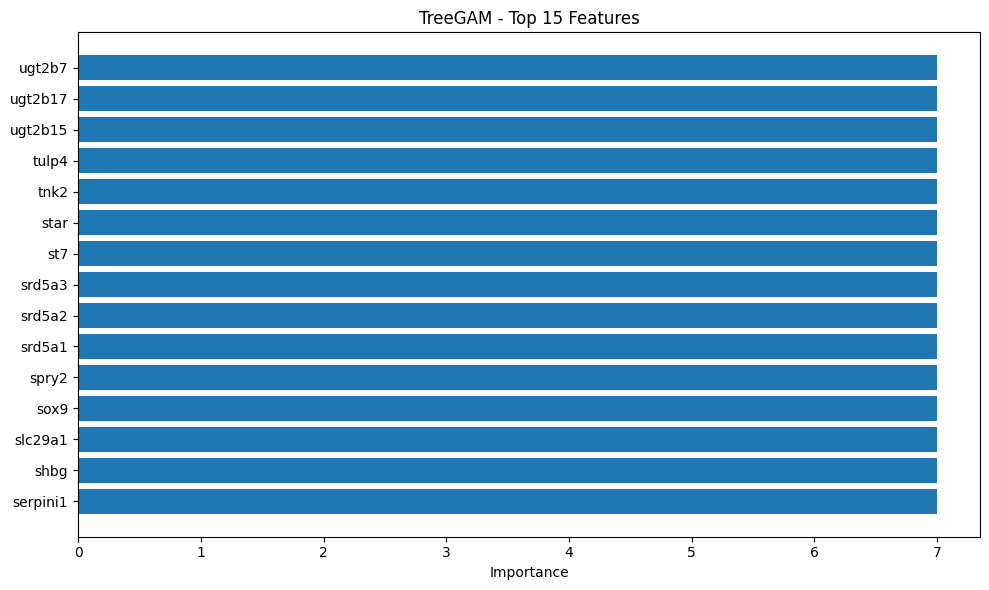

In [ ]:
# TreeGAM Explainability: feature importances
import matplotlib.pyplot as plt
import numpy as np

# Get importances from the internal estimators
importances = np.zeros(X_train_scaled.shape[1])
for est in tgam.estimators_:
    if hasattr(est, 'feature_importances_'):
        importances += est.feature_importances_
    elif hasattr(est, 'coef_'):
        importances += np.abs(est.coef_).flatten()[:X_train_scaled.shape[1]]

if importances.sum() > 0:
    top_idx = np.argsort(importances)[-15:]
    top_names = [X_train_scaled.columns[i] for i in top_idx]
    top_vals = importances[top_idx]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_names)), top_vals)
    plt.yticks(range(len(top_names)), top_names)
    plt.xlabel('Importance')
    plt.title('TreeGAM - Top 15 Features')
    plt.tight_layout()
    plt.show()
else:
    print('TreeGAM: feature importances not available in this version')
    print(f'Model attributes: {[a for a in dir(tgam) if not a.startswith("_")]}')